In [1]:
import numpy as np
import networkx as nx
import re
import pickle
from argparse import Namespace
from itertools import combinations
from collections import Counter

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import PauliEvolutionGate, QAOAAnsatz
from qiskit.circuit import Parameter, ParameterVector
from qiskit.transpiler import Layout
from qiskit.transpiler.passes import LayoutTransformation
from qiskit.converters import dag_to_circuit, circuit_to_dag

from qiskit_aer import AerSimulator
from qiskit_aer.backends.backendconfiguration import AerBackendConfiguration
from qiskit_aer.primitives import SamplerV2 as Sampler

from qiskit_qaoa.hubo.graph_to_hubo_hamiltonian import graph_to_hubo_hamiltonian
from qiskit_qaoa.utils.gfa_utils import gfa_file_to_graph
from qiskit_qaoa.utils.sat_mapper import HigherOrderSatMapper
from qiskit_qaoa.utils.hamiltonian_utils import hamiltonian_to_interactions
from qiskit_qaoa.utils.string_utils import evaluate_sparse_pauli_samples
from qiskit_qaoa.utils.transpiler_passes import ExtendedSwapStrategy
from qiskit_qaoa.utils.pass_managers import get_hubo_pass_manager
from qiskit_qaoa.utils.layout_utils import swap_between_circuit_layouts


In [2]:
rng = np.random.default_rng(seed=1)

args = Namespace(**dict(
    filename='test_N2_W2',
    extra=1,
    fraction_four=0.0,
    fraction_six=1.0,
    timeout=5,
    copy_numbers=[1,1],
    coupling_map='grid',
    reps=2,
    method='Powell',
    shots=10000,
    init='random',
    alpha=1.0
))


p = args.reps


def two_qubit_count(qc: QuantumCircuit):
    ops: dict[str, int] = qc.count_ops()
    return ops.get("cz", 0) + ops.get("rzz", 0) + ops.get("cx", 0) + ops.get("swap", 0)
   
    
def print_circuit_info(qc: QuantumCircuit, circuit_name: str):
    print(f'{circuit_name} has {two_qubit_count(qc)} 2Q gates \
    and {qc.depth(lambda instr: len(instr.qubits) > 1)} 2Q depth')

In [3]:
    
filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{args.filename}.gfa'
graph, n, V, T = gfa_file_to_graph(filepath, args.copy_numbers)
num_qubits = n*T
print(f'Virtual qubits: {num_qubits}')


if args.coupling_map == 'line':
    extended_swap_strat = ExtendedSwapStrategy.from_line(list(range(num_qubits)), num_swap_layers=1000)
elif args.coupling_map == 'grid':
    extended_swap_strat = ExtendedSwapStrategy.from_grid(n, T)
else:
    raise Exception('Invalid coupling map type')

num_physical_qubits = extended_swap_strat._num_vertices
coupling_map = extended_swap_strat._coupling_map
    
coupling_map_edge = list(coupling_map)
physical_qubits = list(coupling_map.physical_qubits)
dual_coupling_map = nx.Graph()

for qubit in physical_qubits:
    edges = [edge for edge in coupling_map_edge if edge[0]==qubit]
    for edge1, edge2 in combinations(edges, 2):
        dual_coupling_map.add_edge(tuple(sorted(edge1)), tuple(sorted(edge2)))
edge_colouring = nx.greedy_color(dual_coupling_map, interchange=True)



print(f'Physical qubits: {num_physical_qubits}')

basis_gates=["sx", "x", "rz", "rzz", "cz", "id", "cx", "swap", "h"]

backend_options = dict(
    method='statevector',
    device='CPU',
    precision='single',
    basis_gates=basis_gates
)


config = AerSimulator._DEFAULT_CONFIGURATION
config["n_qubits"] = num_physical_qubits
config["basis_gates"] = basis_gates
config = AerBackendConfiguration.from_dict(config)
backend = AerSimulator(configuration=config, coupling_map=extended_swap_strat._coupling_map, **backend_options)
backend.set_option("n_qubits", num_physical_qubits)
sampler = Sampler().from_backend(backend)
print(backend.configuration().to_dict()["n_qubits"])

full_hamiltonian = args.reps * graph_to_hubo_hamiltonian(graph, n, T, lamda=10 / args.reps, constraint_terms=1.0)

Virtual qubits: 6
Physical qubits: 6
6
Keeping constraints at times: [0]


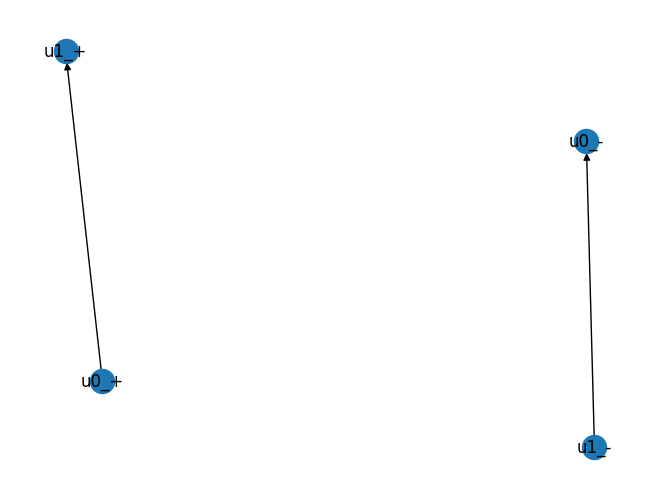

In [4]:
nx.draw(graph, with_labels=True)

In [5]:
# hamiltonians, swap_depths, layouts, compiled_circuits = {}, {}, {}, {}
# terms_to_keep = [tuple(x) for x in np.array_split(np.arange(T-1), p)]
# for layer in range(args.reps):
#     print(f'Getting hamiltonian for layer {layer}')
#     hamiltonian = graph_to_hubo_hamiltonian(graph, n, T, lamda=10, constraint_terms=terms_to_keep[layer])
#     hamiltonians[layer] = hamiltonian
    
#     all_pauli_z = np.array(
#         [i.paulis[0].z for i in hamiltonian]
#     )
#     print(f'Hamiltonian: {len(hamiltonian)}')
#     print(f'Orders: {Counter(np.sum(all_pauli_z, axis=1))}')
    
#     program_interactions = hamiltonian_to_interactions(hamiltonian, args.fraction_four, args.fraction_six)
#     lengths = Counter([len(interaction) for interaction in program_interactions])

#     print(f'Program interactions: {len(program_interactions)}')
#     print(f'Orders: {Counter([len(interaction) for interaction in program_interactions])}')
    
#     mapper = HigherOrderSatMapper(timeout=args.timeout)

#     best_circuit_depth, best_swap_depth, best_layout, best_circuit = np.inf, 0, Layout(), QuantumCircuit(num_physical_qubits)
#     depths = sorted(list(set([int(x) for x in np.linspace(0, len(extended_swap_strat._swap_layers), 10)])))
#     for depth in depths:
#         print('--------------------------------------------------')
#         sat_results = mapper.hubo_max_sat(
#             num_qubits, program_interactions, extended_swap_strat, depth
#         )
#         if sat_results is None:
#             print('No results')
#             continue
#         mapping = sat_results[depth][1]
#         edge_map = dict(mapping)

#         print(f'Cost: {sat_results[depth][0]}')
        
#         donor_qc = QuantumCircuit(num_qubits)
#         layout = Layout({donor_qc.qubits[key]: val for key, val in edge_map.items()})
#         print(edge_map)
#         print(layout)

#         pm = get_hubo_pass_manager(extended_swap_strat, depth, args.extra)

#         new_cost_circ = QuantumCircuit(num_physical_qubits)
#         new_cost_circ.append(PauliEvolutionGate(hamiltonian, time=Parameter("γ")), [layout.get_virtual_bits()[donor_qc.qubits[i]] for i in range(num_physical_qubits)])
#         new_tcost = pm.run(new_cost_circ)
        
#         print_circuit_info(new_tcost, 'Remapped, commuting gate routed circuit')
#         print(new_tcost.count_ops())
        
#         circuit_depth = new_tcost.depth(lambda instr: len(instr.qubits) > 1)
#         if circuit_depth < best_circuit_depth:
#             best_circuit_depth = circuit_depth
#             best_swap_depth = depth
#             best_layout = layout
#             best_circuit = new_tcost
            
#         if sat_results[depth][0] == 0:
#             break
    
#     swap_depths[layer] = best_swap_depth
#     layouts[layer] = best_layout
#     compiled_circuits[layer] = best_circuit
#     print()
#     print()

# to_save = dict(
#     hamiltonians=hamiltonians, swap_depths=swap_depths, layouts=layouts, compiled_circuits=compiled_circuits
# )
# with open(f'./per_layer_results.{args.filename}.reps{args.reps}.pkl', 'wb') as f:
#     pickle.dump(to_save, f)

In [6]:
with open(f'./per_layer_results.{args.filename}.reps{args.reps}.pkl', 'rb') as f:
    data = pickle.load(f)
    

# with open(f'./fake_per_layer_results.{args.filename}.reps{args.reps}.pkl', 'rb') as f:
#     data = pickle.load(f)
    
    
hamiltonians = data["hamiltonians"]
swap_depths = data["swap_depths"]
layouts = data["layouts"]
compiled_circuits = data["compiled_circuits"]

In [9]:
donor_qc = QuantumCircuit(num_qubits)
qaoa_circuit = QuantumCircuit(0, num_qubits)
qaoa_circuit.add_register([layouts[0].get_physical_bits()[i] for i in range(num_qubits)])


mixer_layer = QuantumCircuit(num_qubits)
beta = Parameter("β")
mixer_layer.rx(2 * beta, range(num_qubits))

gammas = ParameterVector("γ", args.reps)
betas = ParameterVector("β", args.reps)

for i in range(num_qubits):
    qaoa_circuit.h(i)

# 0000 0100 0010 0001 0011
# for i in [5, 10, 15, 18, 19]:
#     qaoa_circuit.x(donor_qc.qubits[num_physical_qubits - i - 1])


for layer in range(0, args.reps):
    swap_circuit = swap_between_circuit_layouts(layer-1, compiled_circuits, layouts, extended_swap_strat._coupling_map)
    qaoa_circuit.compose(swap_circuit, range(num_qubits), inplace=True)
    qaoa_circuit.barrier(label=f'SWAP to layout')

    bind_dict = {compiled_circuits[layer].parameters[0]: gammas[layer]}
    bound_cost_layer = compiled_circuits[layer].assign_parameters(bind_dict)
    qaoa_circuit.compose(bound_cost_layer, range(num_qubits), inplace=True)
    qaoa_circuit.barrier(label=f'H_{layer}({gammas[layer]})')
   
    bind_dict = {mixer_layer.parameters[0]: betas[layer]}
    bound_mixer_layer = mixer_layer.assign_parameters(bind_dict)
    qaoa_circuit.compose(bound_mixer_layer, range(num_qubits), inplace=True)
    qaoa_circuit.barrier(label=f'M({betas[layer]})')


layer = args.reps - 1
final_layout = layouts[layer].copy()
for instruction in compiled_circuits[layer].data:
    if instruction.operation.name == 'swap':
        qubits_str = str(instruction.qubits)
        matches = re.findall('index=([0-9]+)', qubits_str)
        if len(matches) == 2:
            final_layout.swap(int(matches[0]), int(matches[1]))
        else:
            raise Exception('Did not find 2 swap indices')

# qaoa_circuit.save_statevector()
for physical, virtual in (
    final_layout.get_physical_bits().items()
):
    # print(physical, donor_qc.find_bit(virtual).index)
    qaoa_circuit.measure(physical, donor_qc.find_bit(virtual).index)


# to_layout = Layout({i: donor_qc.qubits[i] for i in range(num_qubits)})
# transformation_pass = LayoutTransformation(coupling_map, final_layout, to_layout)
# swap_qc = QuantumCircuit(num_qubits)
# swap_qc = dag_to_circuit(transformation_pass.run(circuit_to_dag(swap_qc)))
# qaoa_circuit.compose(swap_qc, range(num_qubits), inplace=True)
# qaoa_circuit.save_statevector()
# # # qaoa_circuit.save_unitary()
# for physical, virtual in (
#     to_layout.get_physical_bits().items()
# ):
#     print(physical, donor_qc.find_bit(virtual).index)
#     qaoa_circuit.measure(physical, donor_qc.find_bit(virtual).index)


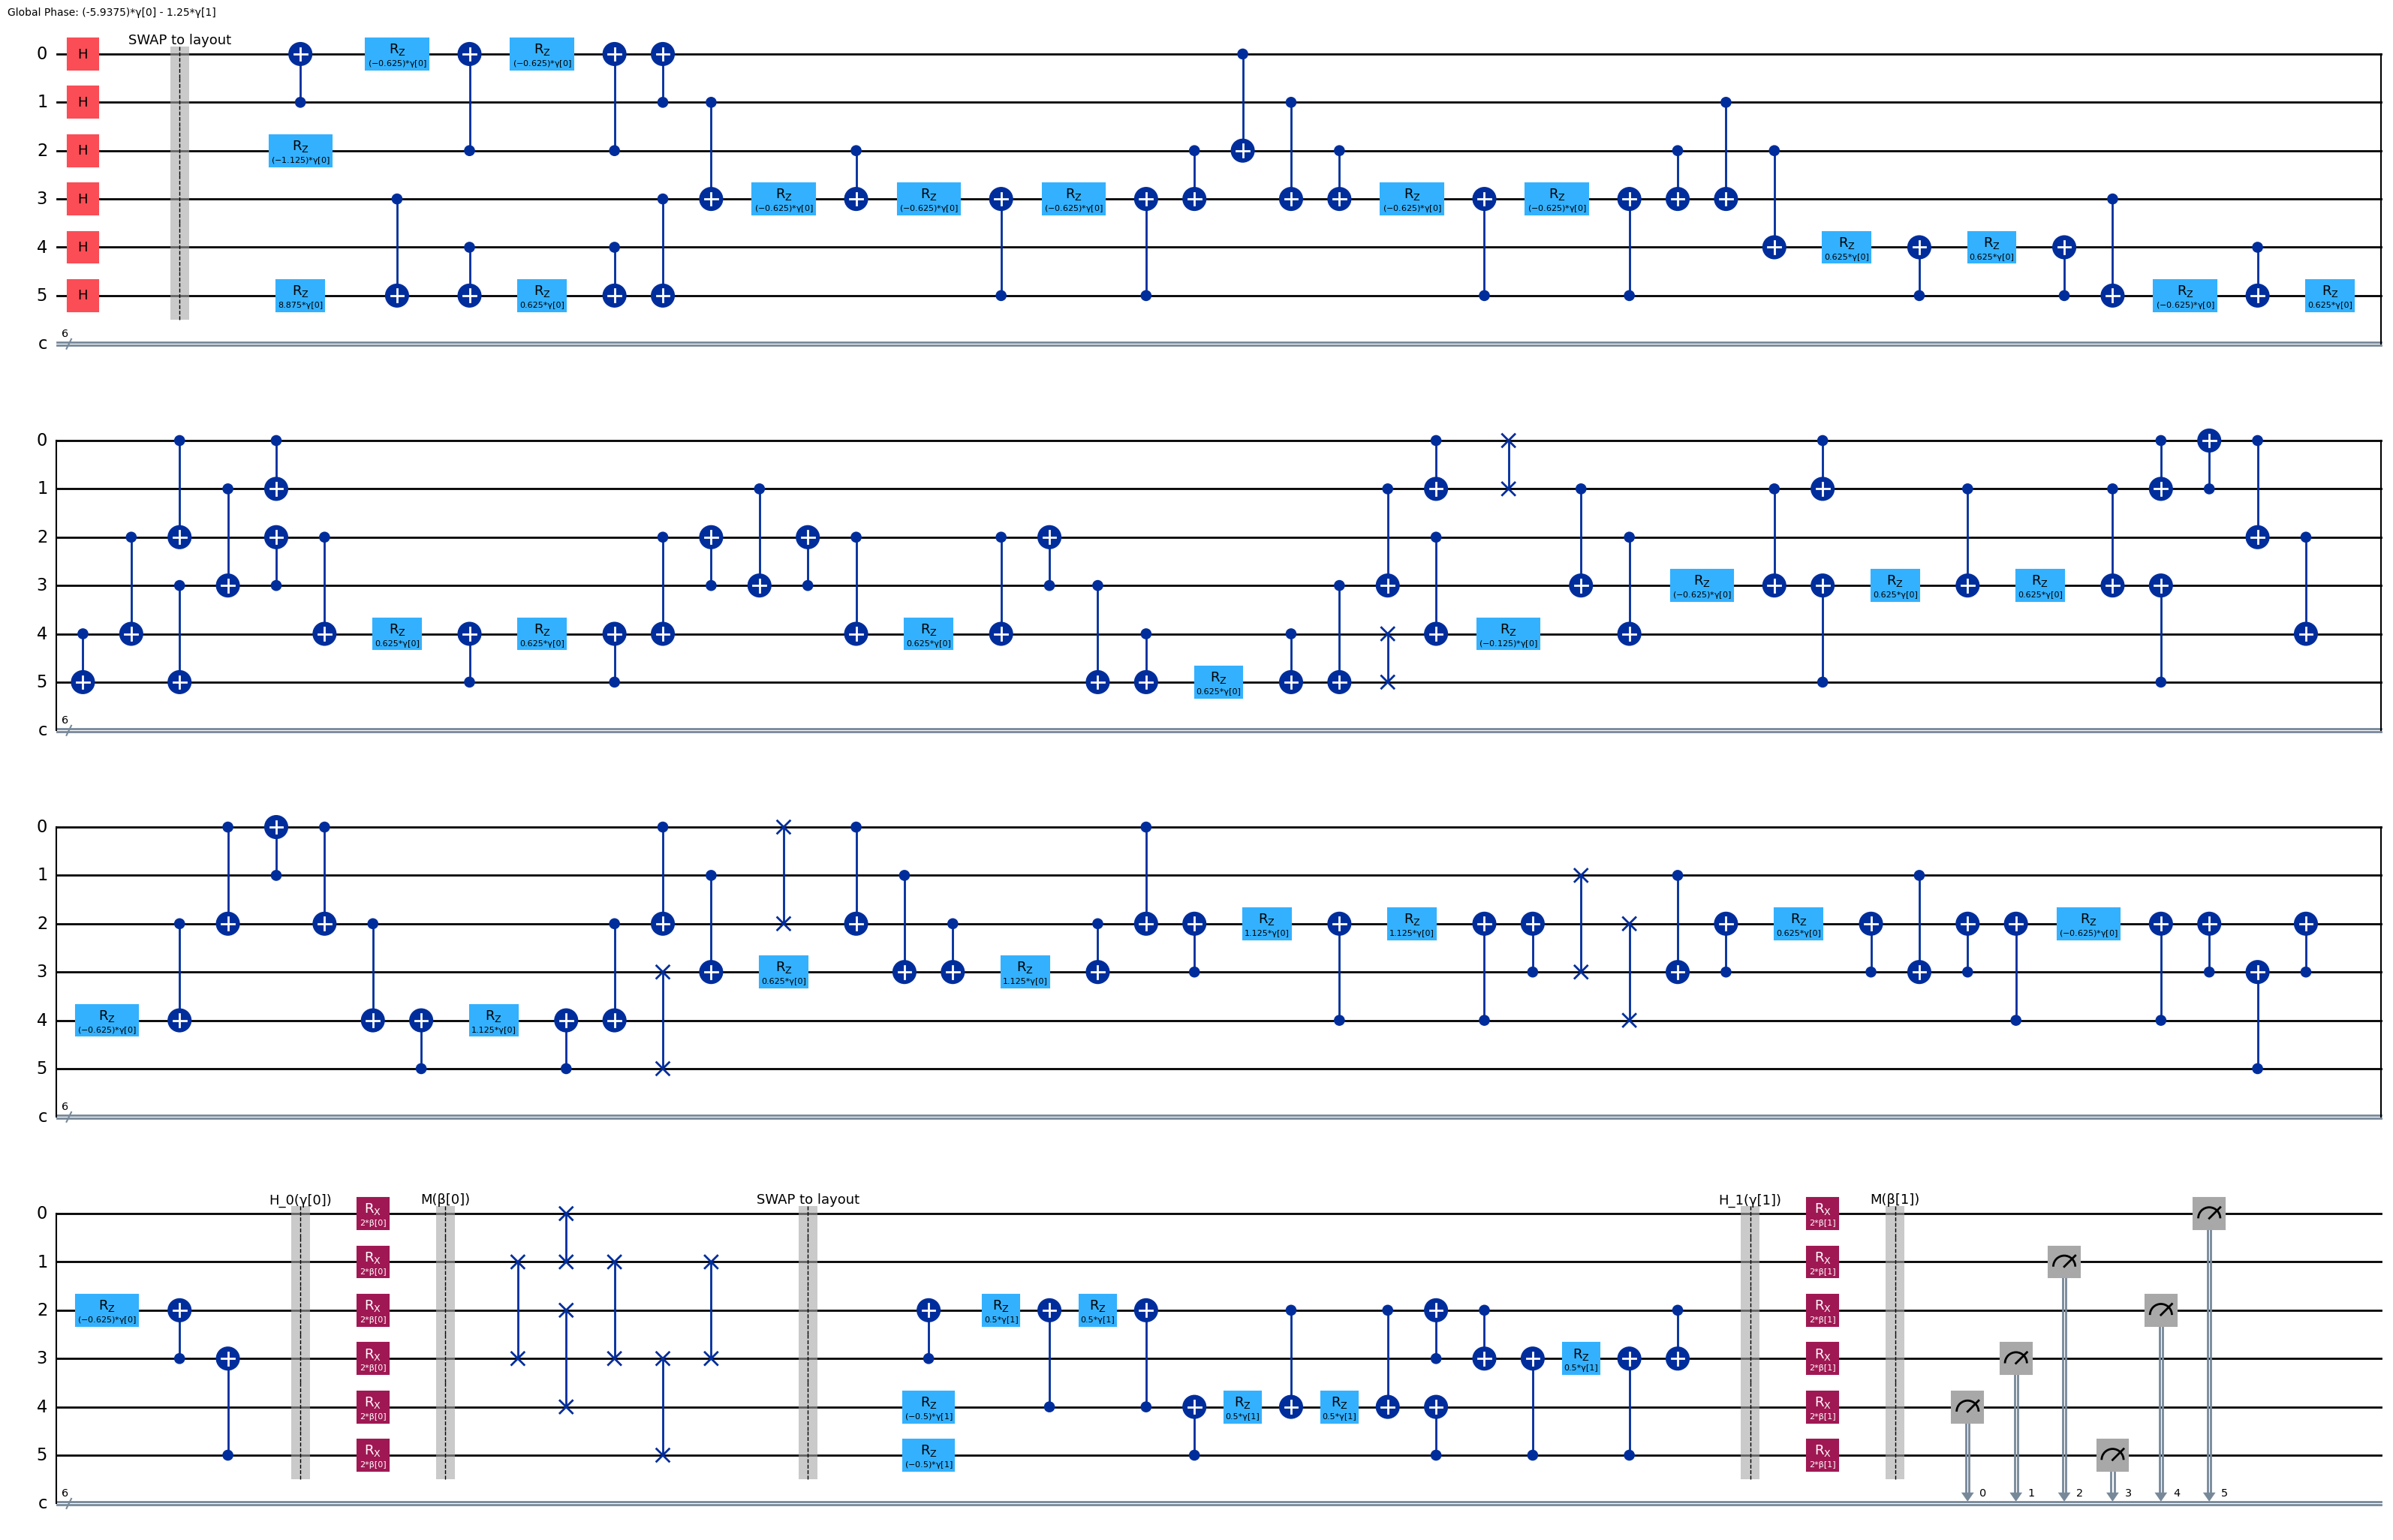

In [19]:
qaoa_circuit.draw(fold= 48, idle_wires=True, output="mpl", filename=f"../out/hubo/qaoa_circuit_{args.filename}.png")

In [ ]:
# params = [0] * (args.reps- 1) + [0] + [1] * args.reps
# params = [0,0,0,0, 1,1,1,1]
print(qaoa_circuit.parameters)
bqaoa_for_backend = qaoa_circuit.assign_parameters({param: params[idx] for idx, param in enumerate(qaoa_circuit.parameters)})

In [ ]:
bqaoa_for_backend.draw(fold=-1)

In [ ]:
scores = {i: np.exp(-1j*i) for i in np.linspace(-140,140, 280+1)}
def get_score(x: complex):
    x = x/ np.abs(x)
    for i in np.linspace(-140,140, 280+1):
        if np.abs(scores[i]- x) < 1e-5:
            return i 
    return x

In [ ]:
res_custom = backend.run(bqaoa_for_backend).result()

In [ ]:
{key:res_custom.get_counts()[key] for key in sorted(list(res_custom.get_counts().keys()))}

In [ ]:
[(x, get_score(res_custom.results[0].data.statevector[int(x)])) for x in np.nonzero(res_custom.results[0].data.statevector)[0]]

In [ ]:
evaluate_sparse_pauli_samples(sorted(list(res_custom.get_counts().keys())), full_hamiltonian)

In [ ]:
def cvar(energies, alpha=1.0):
    sorted_energies = sorted(energies)
    end_idx = int(alpha * len(energies))
    return np.sum(sorted_energies[0:end_idx]) / end_idx


def objective(x: np.ndarray):
    assigned_circuit = qaoa_circuit.assign_parameters(x, inplace=False)
    sampler_job = sampler.run([assigned_circuit], shots=args.shots)
    sampler_result = sampler_job.result()
    counts = sampler_result[0].data.c.get_counts()
    energies = []
    evals = evaluate_sparse_pauli_samples(counts.keys(), full_hamiltonian)
    # print(counts, evals)
    energies = [count * [evals[idx]] for idx, count in enumerate(counts.values())]
    flat_energies = [x for xs in energies for x in xs]
    total_energy = cvar(flat_energies, args.alpha)
    return total_energy

In [ ]:
objective([0,0,0,0,0.5,0.5,0.5,0.5])

In [ ]:
evaluate_sparse_pauli_samples(['00000100001000010011'], full_hamiltonian)

In [ ]:
from scipy.optimize import minimize
result = minimize(
    objective, 
    x0=[0,0,0,0.5,0.5,0.5], 
    method=args.method, 
    bounds=tuple((0,1) for _ in range(2 * p)), 
    options={"maxiter": 100, "maxfev": 10000, "rhobeg": 0.05, "ftol": 1e-7}
)

In [ ]:
custom_unitary = np.asarray(res_custom.results[0].data.unitary)
custom_unitary[np.abs(custom_unitary) < 1e-6] = 0

In [ ]:
ham = sum([hamiltonians[x] if params[args.reps:][x] == 1 else SparsePauliOp('I'*num_physical_qubits, 0) for x in range(args.reps) ])
# ham = sum([hamiltonians[x] if params[x] == 1 else SparsePauliOp('I'*num_physical_qubits, 0) for x in range(args.reps) ])


In [ ]:
np.nonzero(
    np.abs([
        evaluate_sparse_pauli_samples([np.binary_repr(sum([2**i * [[int(c) for c in np.binary_repr(x, num_physical_qubits)][num_physical_qubits-layouts[0].get_virtual_bits()[donor_qc.qubits[j]]-1] for j in range(num_physical_qubits)][i] for i in range(num_physical_qubits)]), num_physical_qubits)], ham)[0] 
        - get_score(custom_unitary[sum(
            [
                2**i * [
                    [int(c) for c in np.binary_repr(x, num_physical_qubits)][num_physical_qubits-layouts[0].get_virtual_bits()[donor_qc.qubits[j]]-1] 
                    for j in range(num_physical_qubits)
                ][i] for i in range(num_physical_qubits)
            ]), x])
    for x in range(2**num_physical_qubits)]) > 1e-6
)

In [ ]:
for x in range(10):
    remapped_x = sum([2**i * [[int(c) for c in np.binary_repr(x, num_physical_qubits)][num_physical_qubits-layouts[0].get_virtual_bits()[donor_qc.qubits[j]]-1] for j in range(num_physical_qubits)][i] for i in range(num_physical_qubits)])
    print(
        np.binary_repr(x, num_physical_qubits),
        # evaluate_sparse_pauli_samples([np.binary_repr(x, num_physical_qubits)], ham)[0],
        get_score(custom_unitary[remapped_x, x]),
        evaluate_sparse_pauli_samples([np.binary_repr(remapped_x, num_physical_qubits)], ham)[0],
    )

In [ ]:
x = 245
print(x)
print([int(c) for c in np.binary_repr(x, num_physical_qubits)])
# remapped_[num_physical_qubits - donor_qc.find_bit(layouts[0].get_physical_bits()[i]).index - 1] = [int(c) for c in np.binary_repr(x, num_physical_qubits)][num_physical_qubits-i-1]
# j = donor_qc.find_bit(layouts[0].get_physical_bits()[i]).index => i = layouts[0].get_virtual_bits()[donor_qc.qubits[j]]
# remapped_[num_physical_qubits - j - 1] = [int(c) for c in np.binary_repr(x, num_physical_qubits)][num_physical_qubits-layouts[0].get_virtual_bits()[donor_qc.qubits[j]]-1]
remapped = [[int(c) for c in np.binary_repr(x, num_physical_qubits)][num_physical_qubits-layouts[0].get_virtual_bits()[donor_qc.qubits[j]]-1] for j in range(num_physical_qubits)]
print(sum([2**i * remapped[i] for i in range(len(remapped))]))
print(
    sum([2**i * [[int(c) for c in np.binary_repr(x, num_physical_qubits)][num_physical_qubits-layouts[0].get_virtual_bits()[donor_qc.qubits[j]]-1] for j in range(num_physical_qubits)][i] for i in range(num_physical_qubits)])
)